
## Adaptación del Dataset - DS3 a las caracteristicas del Articulo 2
---



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import ipywidgets as widgets
import tempfile
from IPython.display import display, clear_output
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Descarga el dataset desde Kaggle:
# https://www.kaggle.com/datasets/jaison14/electrical-fault-detection-and-classification
# Usar el directorio content de Colab
BASE_DIR = "/content"
UPLOAD_DIR = os.path.join(BASE_DIR, "archivos_subidos")


# Widget para subir archivos
uploader = widgets.FileUpload(
    accept='*',
    multiple=True,
    description='Upload Files'
)
output = widgets.Output()

def on_upload_change(change):
    with output:
        clear_output(wait=True)

        if not uploader.value:
            print("No hay archivos seleccionados.")
            return

        # Crear la carpeta (y todos los padres) sin errores si ya existe
        os.makedirs(UPLOAD_DIR, exist_ok=True)
        print(f"Carpeta lista: {UPLOAD_DIR}")

        # Guardar (o sobrescribir) los archivos
        for filename, file_info in uploader.value.items():
            content = file_info['content']
            file_path = os.path.join(UPLOAD_DIR, filename)
            with open(file_path, 'wb') as f:
                f.write(content)
            print(f" {filename} guardado en {file_path}")


        os.chdir(UPLOAD_DIR)
        print(f"Directorio actual cambiado a: {os.getcwd()}")
        # Mostrar solo los archivos cargados
        print("\nArchivos subidos:")
        for filename in uploader.value.keys():
            ruta_completa = os.path.join(UPLOAD_DIR, filename)
            print(f"- El archivo: {filename} \n  Se encuentra en la ruta: -> {ruta_completa}")


uploader.observe(on_upload_change, names='value')

display(uploader)
display(output)

FileUpload(value={}, accept='*', description='Upload Files', multiple=True)

Output()

In [3]:
# Cargar datos (ajusta la ruta si es necesario)
df = pd.read_csv('detect_dataset.csv')

# Ver primeras filas
print("Primeras 5 filas:")
print(df.head())

# Información general
print("\nInformación del dataset:")
print(df.info())

# Estadísticas básicas
print("\nEstadísticas descriptivas:")
print(df.describe())

# Verificar valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Distribución de la variable objetivo
print("\nDistribución de 'Output (S)':")
print(df['Output (S)'].value_counts(normalize=True))

Primeras 5 filas:
   Output (S)          Ia        Ib          Ic        Va        Vb        Vc  \
0           0 -170.472196  9.219613  161.252583  0.054490 -0.659921  0.605431   
1           0 -122.235754  6.168667  116.067087  0.102000 -0.628612  0.526202   
2           0  -90.161474  3.813632   86.347841  0.141026 -0.605277  0.464251   
3           0  -79.904916  2.398803   77.506112  0.156272 -0.602235  0.445963   
4           0  -63.885255  0.590667   63.294587  0.180451 -0.591501  0.411050   

   Unnamed: 7  Unnamed: 8  
0         NaN         NaN  
1         NaN         NaN  
2         NaN         NaN  
3         NaN         NaN  
4         NaN         NaN  

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12001 entries, 0 to 12000
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Output (S)  12001 non-null  int64  
 1   Ia          12001 non-null  float64
 2   Ib          12001 non-nu

## Adaptación del Dataset - DS3 a las caracteristicas del Articulo 2

Para replicar fielmente la metodología del artículo 2, **no podemos usar una corriente de fase aislada (`Ia`) como variable objetivo**, porque el artículo predice la **potencia activa global** (`Global_active_power`) y utiliza la **intensidad global** (`Global_intensity`) como una característica más.

Los datos que tenemos (`Va, Vb, Vc, Ia, Ib, Ic`) nos permiten **calcular** exactamente esas magnitudes globales, emulando el medidor principal de la vivienda francesa.

### Sobre la variable `Output (S)` del dataset original

La columna `Output (S)` es la **variable objetivo para clasificación de fallas** del dataset DS3[electrical-fault-detection-and-classification].

Indica si los datos corresponden a un estado **normal** (`0`) o a una **falla** (`1`). El dataset fue diseñado para **clasificación**, no para predicción de series temporales.

**Esta variable NO se usa en nuestro análisis** porque:

1. **Es una etiqueta de clasificación**, no una variable de entrada para predicción de consumo.
2. **Causaría data leakage**: el modelo aprendería la relación directa entre `Output (S)` y las variables eléctricas.
3. **No tiene sentido físico** para predecir consumo energético.
4. El dataset contiene **mediciones instantáneas**, no una serie temporal continua de consumo horario.

Por lo tanto, `Output (S)` se excluye completamente del pipeline de predicción y detección de anomalías.

---

### Variables seleccionadas para el modelo

Vamos a redefinir las variables de esta manera (obteniendo exactamente **8 features**):

1. **Target (lo que vamos a predecir):**  
   `Global_active_power` =  
   $$ |V_a \cdot I_a| + |V_b \cdot I_b| + |V_c \cdot I_c| $$  
   *(Potencia total absoluta, para evitar que corrientes negativas anulen el consumo).*

2. **Feature 1: Voltaje RMS**  
   En lugar de promediar los valores instantáneos (que pueden ser negativos y se cancelan en sistemas balanceados), calculamos el **voltaje RMS** de las tres fases:  
   $$ Voltage = \sqrt{\frac{V_a^2 + V_b^2 + V_c^2}{3}} $$  
   Este valor **siempre es positivo** y es la magnitud físicamente correcta para representar la tensión del sistema (equivalente al valor que mediría un voltímetro).  
   *Nota: El promedio simple de las tres fases da valores cercanos a cero, lo que no aporta información útil al modelo.*

3. **Feature 2: Intensidad Global**  
   $$ Global\_intensity = \sqrt{I_a^2 + I_b^2 + I_c^2} $$  
   *(similar a la intensidad global del artículo 2).*

4. **Features 3 a 8:**  
   Las 6 variables de fase restantes (`Va, Vb, Vc, Ia, Ib, Ic`) para darle riqueza multidimensional al Transformer, igual que el artículo 2 usa las submediciones (`Sub_metering_1..4`).

---

**Nota:** Todas estas variables se calculan a partir del dataset original `detect_dataset.csv` y se normalizan con `MinMaxScaler` antes de crear las secuencias temporales.

In [13]:
from sklearn.preprocessing import MinMaxScaler

# =============================================
# 1. LIMPIEZA INICIAL
# =============================================
df_clean = df.drop(columns=['Unnamed: 7', 'Unnamed: 8'])

# =============================================
# 2. CREACIÓN DE FEATURES Y TARGET (CON RMS)
# =============================================

# --- Target: Potencia Activa Global ---
df_clean['Global_active_power'] = (df_clean['Va'] * np.abs(df_clean['Ia'])) + \
                                  (df_clean['Vb'] * np.abs(df_clean['Ib'])) + \
                                  (df_clean['Vc'] * np.abs(df_clean['Ic']))

# --- Feature 1: Voltaje RMS (en lugar de promedio) ---
df_clean['Voltage'] = np.sqrt((df_clean['Va']**2 + df_clean['Vb']**2 + df_clean['Vc']**2) / 3)

# --- Feature 2: Intensidad Global ---
df_clean['Global_intensity'] = np.sqrt(df_clean['Ia']**2 + df_clean['Ib']**2 + df_clean['Ic']**2)

# --- Features ---
feature_cols = ['Voltage', 'Global_intensity', 'Va', 'Vb', 'Vc', 'Ia', 'Ib', 'Ic']
target_col = 'Global_active_power'

print("Variables creadas correctamente (usando RMS para Voltage).")
print(f"Features (8): {feature_cols}")
print(f"Target: {target_col}")

# =============================================
# 3. VISUALIZACIÓN DEL NUEVO DATAFRAME (SIN NORMALIZAR)
# =============================================
print("\n" + "="*70)
print(" MUESTRA DEL DATASET CON VOLTAJE RMS (SIN NORMALIZAR)")
print("="*70)
print("Primeras 10 filas:")
print(df_clean[feature_cols + [target_col]].head(10).to_string())

# =============================================
# 4. ESTADÍSTICAS DESCRIPTIVAS
# =============================================
print("\n" + "="*70)
print(" ESTADÍSTICAS DE LAS NUEVAS VARIABLES GLOBALES (con RMS)")
print("="*70)
print(df_clean[['Global_active_power', 'Voltage', 'Global_intensity']].describe())

# =============================================
# 5. NORMALIZACIÓN MIN-MAX
# =============================================
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df_clean[feature_cols])
y_scaled = scaler_y.fit_transform(df_clean[[target_col]]).ravel()

df_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
df_scaled[target_col] = y_scaled

# =============================================
# 6. VISUALIZACIÓN DEL DATAFRAME NORMALIZADO
# =============================================
print("\n" + "="*70)
print(" MUESTRA DEL DATASET NORMALIZADO (Min-Max)")
print("="*70)
print("Primeras 10 filas:")
print(df_scaled.head(10).to_string())
print("\nEstadísticas después de normalización:")
print(df_scaled.describe().round(4))

# =============================================
# 7. CREACIÓN DE SECUENCIAS
# =============================================
WINDOW = 23

def create_sequences(data, feature_cols, target_col, window=23):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[feature_cols].iloc[i:i+window].values)
        y.append(data[target_col].iloc[i+window])
    return np.array(X), np.array(y)

X, y = create_sequences(df_scaled, feature_cols, target_col, WINDOW)

print(f"\nDimensiones de X (muestras, timesteps, features): {X.shape}")
print(f"Dimensiones de y: {y.shape}")

# =============================================
# 8. DIVISIÓN TRAIN/TEST
# =============================================
train_size = int(len(X) * 0.86)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"\nTrain: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Test:  X_test {X_test.shape}, y_test {y_test.shape}")

# =============================================
# 9. GUARDAR PREPROCESADO
# =============================================
np.savez('/content/ds3_preprocessed_rms.npz',
         X_train=X_train, y_train=y_train,
         X_test=X_test, y_test=y_test,
         scaler_X=scaler_X, scaler_y=scaler_y,
         feature_cols=feature_cols, target_col=target_col)

print("\n Datos preprocesados guardados en 'ds3_preprocessed_rms.npz'")

Variables creadas correctamente (usando RMS para Voltage).
Features (8): ['Voltage', 'Global_intensity', 'Va', 'Vb', 'Vc', 'Ia', 'Ib', 'Ic']
Target: Global_active_power

 MUESTRA DEL DATASET CON VOLTAJE RMS (SIN NORMALIZAR)
Primeras 10 filas:
    Voltage  Global_intensity        Va        Vb        Vc          Ia        Ib          Ic  Global_active_power
0  0.518013        234.836467  0.054490 -0.659921  0.605431 -170.472196  9.219613  161.252583           100.832116
1  0.476950        168.674838  0.102000 -0.628612  0.526202 -122.235754  6.168667  116.067087            69.665037
2  0.447876        124.898298  0.141026 -0.605277  0.464251  -90.161474  3.813632   86.347841            50.493866
3  0.441962        111.345171  0.156272 -0.602235  0.445963  -79.904916  2.398803   77.506112            45.607142
4  0.428719         89.932639  0.180451 -0.591501  0.411050  -63.885255  0.590667   63.294587            37.196045
5  0.425896         79.849734  0.193414 -0.590695  0.397281  -55.95

## Configuración de Parámetros para Validación Cruzada (Basada en el Artículo 2)

Para garantizar la reproducibilidad de la metodología propuesta en el **artículo 2** (Zhang et al., "Power Consumption Predicting and Anomaly Detection Based on Transformer and K-Means") sobre el dataset **DS3** (Kaggle), se han extraído y fijado los siguientes parámetros, tal como se describen explícitamente en la sección **4.3 Model Development** y **5. EXPERIMENT RESULTS** del artículo original.

---

### 1. Preprocesamiento y Partición de Datos

- **Ventana deslizante (Sliding Window):** `23` horas de entrada para predecir la hora 24.  
- **Partición Train/Test:**  
  - **Entrenamiento (Train):** `86%` de los datos (equivalente a 1.240 días en el artículo original).  
  - **Prueba (Test):** `14%` de los datos (equivalente a 200 días en el artículo original).  
- **Normalización:** Se aplica `Min-Max Scaling` a todas las características (features) y a la variable objetivo (target) para estabilizar el entrenamiento y acelerar la convergencia del modelo.

---

### 2. Variables Adaptadas para DS3

El dataset original del artículo 2 contiene 8 variables: `Global_active_power` (target), `Global_reactive_power`, `Voltage`, `Global_intensity`, `Sub_metering_1`, `Sub_metering_2`, `Sub_metering_3`, `Sub_metering_4`.

Para adaptar DS3 a esta estructura, se calcularon las siguientes variables a partir de las mediciones de fase (`Va, Vb, Vc, Ia, Ib, Ic`):

| Variable en DS3 | Cálculo | Equivalente en artículo 2 |
|----------------|---------|---------------------------|
| **`Global_active_power`** (Target) | `|Va·Ia| + |Vb·Ib| + |Vc·Ic|` | `Global_active_power` |
| **`Voltage`** (Feature 1) | `√((Va² + Vb² + Vc²) / 3)` (RMS) | `Voltage` |
| **`Global_intensity`** (Feature 2) | `√(Ia² + Ib² + Ic²)` | `Global_intensity` |
| **`Va, Vb, Vc, Ia, Ib, Ic`** (Features 3–8) | Variables originales de fase | `Sub_metering_1..4` (features auxiliares) |

> **Nota:** Se utiliza **voltaje RMS** en lugar del promedio aritmético, ya que el promedio de las tres fases en sistemas balanceados tiende a cero, mientras que el RMS es la magnitud físicamente correcta y equivalente a la tensión eficaz del sistema.

---

### 3. Modelos Implementados

Siguiendo el artículo 2, se entrenan y comparan los siguientes modelos:

| Modelo | Descripción | Propósito |
|--------|-------------|-----------|
| **Transformer** | 2 capas, 4 cabezas de atención, 8 features de entrada, 23 timesteps | Predicción de potencia |
| **Transformer + K-Means** | Transformer + optimización con K-Means (k=10) | Predicción optimizada |
| **LSTM** | 2 capas LSTM (32 unidades) con Dropout(0.2) | Referencia de comparación |
| **K-Means puro** | Clustering (k=10) sobre datos aplanados | Detección de anomalías por distancia al centroide |

---

### 4. Configuración de Entrenamiento

| Parámetro | Valor |
|-----------|-------|
| **Función de Pérdida** | `MSE` (Mean Squared Error) |
| **Optimizador** | `Adam` |
| **Épocas (Transformer)** | `300` (con EarlyStopping paciencia=20) |
| **Épocas (LSTM)** | `50` |
| **Tamaño de Lote (Batch Size)** | `200` muestras (Transformer) / `64` (LSTM) |
| **Número de Clústeres (K-Means)** | `10` (probados: 2, 5, 8, 10, 11, 15) |

---

### 5. Detección de Anomalías

El método de detección de anomalías se basa en el **score** descrito en las ecuaciones (10) y (11) del artículo:

$$ \text{score}_t = \frac{|\text{predicted}_t - \text{test}_t|}{\text{avg}_{i \in T}(|\text{predicted}_i - \text{test}_i|)} $$

$$ \text{score}_t^{\text{norm}} = \frac{\text{score}_t - \min(\text{score})}{\max(\text{score}) - \min(\text{score})} $$

- **Umbral:** `0.45` (establecido experimentalmente en el artículo).  
- **Puntos anómalos:** aquellos con `score_norm > 0.45`.

#### Inserción de Anomalías Artificiales

Para evaluar la detección, se siguen las instrucciones de la sección 5.2 del artículo:

- En el conjunto de prueba, se selecciona aleatoriamente un valor por cada bloque de 24 horas y se **duplica** (multiplicar por 2).  
- Esto genera aproximadamente `(n_test / 24)` anomalías artificiales.  
- Se comparan las detecciones de los tres métodos contra estas anomalías insertadas.


---

### 6. Métricas de Evaluación

| Métrica | Descripción |
|---------|-------------|
| **RMSE** | Root Mean Squared Error (para predicción) |
| **Precisión** | Proporción de anomalías detectadas correctamente sobre el total de detecciones |
| **Recall** | Proporción de anomalías reales detectadas |
| **F1-Score** | Media armónica de precisión y recall |

---

### 7. Tabla de Resultados Esperados (similar a Tabla 2 del artículo)

| Method | Precisión | Recall | F1 | RMSE (predicción) |
|--------|-----------|--------|----|--------------------|
| **K-Means puro** | ~0.82 | ~0.28 | ~0.42 | — |
| **LSTM** | ~0.74 | ~0.60 | ~0.66 | ~0.91 |
| **Transformer + K-Means (nuestro método)** | ~0.80 | ~0.66 | ~0.72 | ~0.74 |

---

### 8. Artefactos Generados

| Archivo | Descripción |
|---------|-------------|
| `ds3_preprocessed_rms.npz` | Datos preprocesados (X_train, X_test, y_train, y_test, scalers) |
| `transformer_model.h5` | Modelo Transformer entrenado |
| `kmeans_model.pkl` | K-Means para optimización de predicción |
| `lstm_model.h5` | Modelo LSTM entrenado |
| `kmeans_anomaly_model.pkl` | K-Means para detección de anomalías |
| `scaler_X.pkl`, `scaler_y.pkl` | Objetos MinMaxScaler |
| `training_history.npz` | Historial de pérdidas del Transformer |
| `validation_results.csv` | Métricas finales (RMSE, precisión, recall, F1) |
| `validation_results.png` | Gráficos de comparación de predicciones y detección de anomalías |

---


In [5]:
!pip install tensorflow scikit-learn joblib

In [16]:
# ==================================================================
# FASE 3a: ENTRENAMIENTO DEL TRANSFORMER + K-MEANS (OPTIMIZACIÓN)
# Basado en el artículo 2 y en el código original del autor
# ==================================================================

import os
os.chdir("/content")  # Asegurar directorio correcto

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.cluster import KMeans
import joblib

BASE_DIR = "/content"

# ------------------------------------------------------------------
# 1. Cargar datos procesados
# ------------------------------------------------------------------
print("Cargando datos procesados...")
data = np.load(f"{BASE_DIR}/ds3_preprocessed_rms.npz", allow_pickle=True)
X_train = data["X_train"]
y_train = data["y_train"]
X_test = data["X_test"]
y_test = data["y_test"]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

# ------------------------------------------------------------------
# 2. Entrenar K-Means sobre y_train (k=10)
# ------------------------------------------------------------------
print("\nEntrenando K-Means sobre y_train (k=10)...")
kmeans_opt = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans_opt.fit(y_train.reshape(-1, 1))
centroids = kmeans_opt.cluster_centers_.flatten()
print(f"Centroides: {centroids}")

joblib.dump(kmeans_opt, f"{BASE_DIR}/kmeans_model.pkl")
print("K-Means guardado en 'kmeans_model.pkl'")

# ------------------------------------------------------------------
# 3. Definir Transformer
# ------------------------------------------------------------------
def transformer_encoder(inputs, head_size=8, num_heads=4, ff_dim=32, dropout=0.1):
    attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size)
    x = attention(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + inputs)
    x_ff = layers.Dense(ff_dim, activation="relu")(x)
    x_ff = layers.Dense(inputs.shape[-1])(x_ff)
    x_ff = layers.Dropout(dropout)(x_ff)
    return layers.LayerNormalization(epsilon=1e-6)(x + x_ff)

def build_transformer(input_shape, num_layers=2, head_size=8, num_heads=4, ff_dim=32, dropout=0.1):
    inputs = layers.Input(shape=input_shape)
    x = inputs
    for _ in range(num_layers):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)
    x = layers.Lambda(lambda t: t[:, -1, :])(x)
    outputs = layers.Dense(1)(x)
    return Model(inputs, outputs)

INPUT_SHAPE = (23, 8)
transformer = build_transformer(INPUT_SHAPE, num_layers=2, head_size=2, num_heads=4, ff_dim=32, dropout=0.1)
transformer.summary()

# ------------------------------------------------------------------
# 4. Compilar
# ------------------------------------------------------------------
transformer.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                    loss='mse', metrics=['mae'])

# ------------------------------------------------------------------
# 5. Entrenar
# ------------------------------------------------------------------
print("\nIniciando entrenamiento del Transformer...")
history = transformer.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=300,
    batch_size=200,
    verbose=1,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint(f"{BASE_DIR}/best_transformer.keras", save_best_only=True, monitor='val_loss')
    ]
)

transformer.save(f"{BASE_DIR}/transformer_final.keras")
print("Transformer guardado.")

joblib.dump(history.history, f"{BASE_DIR}/training_history.pkl")
print("Historial guardado.")

print("\nEntrenamiento del Transformer completado.")

Cargando datos procesados...
X_train: (10301, 23, 8), y_train: (10301,)
X_test: (1677, 23, 8), y_test: (1677,)

Entrenando K-Means sobre y_train (k=10)...
Centroides: [0.36025018 0.66665284 0.54608692 0.18519321 0.952794   0.44980085
 0.78311995 0.04510666 0.2752222  0.49860481]
K-Means guardado en 'kmeans_model.pkl'


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 23, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 23, 8)     │        288 │ input_layer_4[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 23, 8)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 23, 8)     │          0 │ dropout_25[0][0], │
│                     │                   │            │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 23, 8)     │         16 │ add_12[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 23, 32)    │        288 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 23, 8)     │        264 │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 23, 8)     │          0 │ dense_20[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 23, 8)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_26[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 23, 8)     │         16 │ add_13[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 23, 8)     │        288 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_28          │ (None, 23, 8)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 23, 8)     │          0 │ dropout_28[0][0], │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 23, 8)     │         16 │ add_14[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 23, 32)    │        288 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 23, 8)     │        264 │ dense_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_29          │ (None, 23, 8)     │          0 │ dense_22[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_15 (Add)        │ (None, 23, 8)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_29[0][0]

 Total params: 1,753 (6.85 KB)

 Trainable params: 1,753 (6.85 KB)

 Non-trainable params: 0 (0.00 B)


Iniciando entrenamiento del Transformer...
Epoch 1/300
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 181ms/step - loss: 0.3692 - mae: 0.4346 - val_loss: 0.0077 - val_mae: 0.0696
Epoch 2/300
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0311 - mae: 0.1230 - val_loss: 0.0040 - val_mae: 0.0474
Epoch 3/300
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0256 - mae: 0.1105 - val_loss: 0.0037 - val_mae: 0.0452
Epoch 4/300
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0236 - mae: 0.1063 - val_loss: 0.0036 - val_mae: 0.0448
Epoch 5/300
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0220 - mae: 0.1033 - val_loss: 0.0035 - val_mae: 0.0439
Epoch 6/300
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0215 - mae: 0.1021 - val_loss: 0.0035 - val_mae: 0.0444
Epoch 7/300
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0207 - mae: 0.1004 - val_loss: 0.0035 - val_mae: 0.0443
Epoch 8/300
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0201 - mae: 0.0998 - val_loss: 0.0034 - val_mae: 0.0434
Epoch 9/300
47/47

In [17]:
# ==================================================================
# ENTRENAMIENTO DE MODELOS BASELINE (LSTM y K-MEANS)
# Basado en el artículo 2 y en el código original del autor
# ==================================================================

import os
os.chdir("/content")

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.cluster import KMeans
import joblib

BASE_DIR = "/content"

# ------------------------------------------------------------------
# 1. Cargar datos
# ------------------------------------------------------------------
print("Cargando datos procesados...")
data = np.load(f"{BASE_DIR}/ds3_preprocessed_rms.npz", allow_pickle=True)
X_train = data["X_train"]
y_train = data["y_train"].flatten()
X_test = data["X_test"]
y_test = data["y_test"].flatten()

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

# ------------------------------------------------------------------
# 2. LSTM
# ------------------------------------------------------------------
LSTM_PATH = f"{BASE_DIR}/lstm_model.keras"
if os.path.exists(LSTM_PATH):
    print(f"LSTM ya existe en {LSTM_PATH}. Se omite entrenamiento.")
else:
    print("\nEntrenando LSTM...")
    lstm = Sequential([
        LSTM(64, return_sequences=True, input_shape=(23, 8)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
    early_stop = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
    lstm.fit(X_train, y_train, epochs=100, batch_size=200, validation_split=0.1,
             callbacks=[early_stop], verbose=1)
    lstm.save(LSTM_PATH)
    print(f"LSTM guardado en {LSTM_PATH}")

# ------------------------------------------------------------------
# 3. K-Means baseline (para detección de anomalías)
# ------------------------------------------------------------------
print("\nEntrenando K-Means baseline (k=10)...")
X_train_flat = X_train.reshape(X_train.shape[0], -1)
kmeans_base = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans_base.fit(X_train_flat)
joblib.dump(kmeans_base, f"{BASE_DIR}/kmeans_baseline.pkl")
print("K-Means baseline guardado.")

print("\nFase 3b completada.")

Cargando datos procesados...
X_train: (10301, 23, 8), y_train: (10301,)

Entrenando LSTM...
Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0375 - mae: 0.1441 - val_loss: 0.0049 - val_mae: 0.0538
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0222 - mae: 0.1117 - val_loss: 0.0053 - val_mae: 0.0567
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0206 - mae: 0.1083 - val_loss: 0.0060 - val_mae: 0.0612
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0182 - mae: 0.1014 - val_loss: 0.0048 - val_mae: 0.0534
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0155 - mae: 0.0920 - val_loss: 0.0067 - val_mae: 0.0634
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0143 - mae: 0.0892 - val_loss: 0.0039 - val_mae: 0.0469
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0118 - mae: 0.0803 - val_loss: 0.0025 - val_mae: 0.0352
Epoch 8/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0099 - mae: 0.0739 - val

# Evaluación y Detección de Anomalías usando el modelo entrenado
El artículo reporta métricas específicas que debemos intentar reproducir. Usaremos el modelo guardado (best_transformer.keras o transformer_final.keras) y el K-Means entrenado.

In [20]:
# ==================================================================
# FASE 4: EVALUACIÓN Y DETECCIÓN DE ANOMALÍAS (CORREGIDO)
# ==================================================================

import os
os.chdir("/content")

import numpy as np
import tensorflow as tf
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Habilitar deserialización de Lambdas (por la capa Lambda del Transformer)
tf.keras.config.enable_unsafe_deserialization()

BASE_DIR = "/content"

# ------------------------------------------------------------------
# 1. Cargar datos y modelos
# ------------------------------------------------------------------
print("Cargando datos...")
data = np.load(f"{BASE_DIR}/ds3_preprocessed_rms.npz", allow_pickle=True)
X_test = data["X_test"]
y_test_norm = data["y_test"].flatten()

# Cargar scaler_y
scaler_y = joblib.load(f"{BASE_DIR}/scaler_y.pkl")
min_active = scaler_y.data_min_[0]
max_active = scaler_y.data_max_[0]

def inverse_transform_active(norm_value):
    return norm_value * (max_active - min_active) + min_active

# Cargar Transformer
print("Cargando modelo Transformer...")
transformer = tf.keras.models.load_model(
    f"{BASE_DIR}/best_transformer.keras",
    compile=False,
    safe_mode=False
)

# Cargar K-Means (entrenado sobre y_train)
print("Cargando K-Means (optimización)...")
kmeans_opt = joblib.load(f"{BASE_DIR}/kmeans_model.pkl")

# Obtener centroides directamente (están en el espacio de y_train, 1D)
centroids = kmeans_opt.cluster_centers_.flatten()
print(f"Centroides de K-Means (en espacio de y): {centroids}")

# Cargar LSTM (opcional)
lstm_path = f"{BASE_DIR}/lstm_model.keras"
if os.path.exists(lstm_path):
    lstm = tf.keras.models.load_model(lstm_path, compile=False, safe_mode=False)
    print("Modelo LSTM cargado.")
else:
    lstm = None
    print("Modelo LSTM no encontrado. Se omite comparación.")

# ------------------------------------------------------------------
# 2. Predicción y RMSE (Transformer + K-Means)
# ------------------------------------------------------------------
print("\nGenerando predicciones con Transformer + K-Means...")
y_pred_trans = transformer.predict(X_test, verbose=0).flatten()

# Corregir con K-Means: asignar cada predicción al centroide más cercano
y_pred_corrected = np.array([
    centroids[np.argmin(np.abs(y_pred_trans[i] - centroids))]
    for i in range(len(y_pred_trans))
])

y_test_orig = inverse_transform_active(y_test_norm)
y_pred_orig = inverse_transform_active(y_pred_corrected)

rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
print(f"RMSE (Transformer + K-Means) en escala original: {rmse:.4f} kW")

if lstm is not None:
    y_pred_lstm = lstm.predict(X_test, verbose=0).flatten()
    y_pred_lstm_orig = inverse_transform_active(y_pred_lstm)
    rmse_lstm = np.sqrt(mean_squared_error(y_test_orig, y_pred_lstm_orig))
    print(f"RMSE (LSTM) en escala original: {rmse_lstm:.4f} kW")
else:
    rmse_lstm = None

# ------------------------------------------------------------------
# 3. Inyección de anomalías (1 por día, multiplicador=2)
# ------------------------------------------------------------------
hours_per_day = 24
num_days_test = len(y_test_orig) // hours_per_day
np.random.seed(42)
y_test_with_anomalies = y_test_orig.copy()
anomaly_labels = np.zeros(len(y_test_orig), dtype=int)

for day in range(num_days_test):
    base_idx = day * hours_per_day
    if base_idx + hours_per_day <= len(y_test_orig):
        hour_offset = np.random.randint(0, hours_per_day)
        anomaly_idx = base_idx + hour_offset
        y_test_with_anomalies[anomaly_idx] *= 2
        anomaly_labels[anomaly_idx] = 1

print(f"\nAnomalías insertadas: {np.sum(anomaly_labels)} (1 por día)")

# Normalizar anomalías
y_test_norm_anom = (y_test_with_anomalies - min_active) / (max_active - min_active)

# ------------------------------------------------------------------
# 4. Cálculo de scores (ecuaciones 10 y 11 del artículo)
# ------------------------------------------------------------------
abs_errors = np.abs(y_pred_corrected - y_test_norm_anom)
mean_abs_error = np.mean(abs_errors)
scores = abs_errors / mean_abs_error
scores_norm = (scores - np.min(scores)) / (np.max(scores) - np.min(scores))

# ------------------------------------------------------------------
# 5. Análisis de umbrales
# ------------------------------------------------------------------
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
results = []
for th in thresholds:
    y_pred = (scores_norm > th).astype(int)
    acc = accuracy_score(anomaly_labels, y_pred)
    prec = precision_score(anomaly_labels, y_pred, zero_division=0)
    rec = recall_score(anomaly_labels, y_pred, zero_division=0)
    f1 = f1_score(anomaly_labels, y_pred, zero_division=0)
    detections = y_pred.sum()
    results.append([th, acc, prec, rec, f1, detections])

df_thresholds = pd.DataFrame(results, columns=['Umbral', 'Accuracy', 'Precision', 'Recall', 'F1', 'Detecciones'])

print("\n" + "="*80)
print("TABLA 1: MÉTRICAS PARA DIFERENTES UMBRALES")
print("="*80)
print(df_thresholds.to_string(index=False))

# Mejores valores
best_precision = df_thresholds.loc[df_thresholds['Precision'].idxmax()]
best_recall = df_thresholds.loc[df_thresholds['Recall'].idxmax()]
best_f1 = df_thresholds.loc[df_thresholds['F1'].idxmax()]

print("\n" + "="*80)
print("MEJORES VALORES POR MÉTRICA")
print("="*80)
print(f"Mejor Precision:  Umbral = {best_precision['Umbral']:.2f}  →  Precision = {best_precision['Precision']:.4f}")
print(f"Mejor Recall:     Umbral = {best_recall['Umbral']:.2f}  →  Recall    = {best_recall['Recall']:.4f}")
print(f"Mejor F1-Score:   Umbral = {best_f1['Umbral']:.2f}  →  F1        = {best_f1['F1']:.4f}")

# ------------------------------------------------------------------
# 6. Umbral del artículo (0.45)
# ------------------------------------------------------------------
threshold_article = 0.45
y_pred_article = (scores_norm > threshold_article).astype(int)
acc_art = accuracy_score(anomaly_labels, y_pred_article)
prec_art = precision_score(anomaly_labels, y_pred_article, zero_division=0)
rec_art = recall_score(anomaly_labels, y_pred_article, zero_division=0)
f1_art = f1_score(anomaly_labels, y_pred_article, zero_division=0)
detections_art = y_pred_article.sum()

print("\n" + "="*80)
print(f"RESULTADOS CON EL UMBRAL DEL ARTÍCULO ({threshold_article})")
print("="*80)
print(f"Accuracy : {acc_art:.4f}")
print(f"Precision: {prec_art:.4f}")
print(f"Recall   : {rec_art:.4f}")
print(f"F1-Score : {f1_art:.4f}")
print(f"RMSE     : {rmse:.4f} kW")
print(f"Anomalías detectadas: {detections_art} de {len(anomaly_labels)}")

# Matriz de confusión
tp = np.sum((anomaly_labels == 1) & (y_pred_article == 1))
fp = np.sum((anomaly_labels == 0) & (y_pred_article == 1))
fn = np.sum((anomaly_labels == 1) & (y_pred_article == 0))
tn = np.sum((anomaly_labels == 0) & (y_pred_article == 0))
print("\nMatriz de confusión (Umbral 0.45):")
print(f"  VP: {tp}, FP: {fp}, FN: {fn}, VN: {tn}")
print("="*80)

# ------------------------------------------------------------------
# 7. Tabla comparativa con el artículo (Tabla 2)
# ------------------------------------------------------------------
print("\n" + "="*80)
print("TABLA 2: COMPARACIÓN CON LOS VALORES REPORTADOS EN EL ARTÍCULO")
print("="*80)
comparison = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'RMSE (kW)'],
    'Artículo (Tabla 2)': [0.970, 0.800, 0.660, 0.720, 0.740],
    'Nuestro resultado': [acc_art, prec_art, rec_art, f1_art, rmse]
})
print(comparison.to_string(index=False))
print("="*80)

# Guardar resultados
df_thresholds.to_csv(f"{BASE_DIR}/threshold_analysis.csv", index=False)
comparison.to_csv(f"{BASE_DIR}/comparison_article.csv", index=False)
print("\nResultados guardados en 'threshold_analysis.csv' y 'comparison_article.csv'.")

Cargando datos...
Cargando modelo Transformer...
Cargando K-Means (optimización)...
Centroides de K-Means (en espacio de y): [0.36025018 0.66665284 0.54608692 0.18519321 0.952794   0.44980085
 0.78311995 0.04510666 0.2752222  0.49860481]
Modelo LSTM cargado.

Generando predicciones con Transformer + K-Means...
RMSE (Transformer + K-Means) en escala original: 13.1421 kW
RMSE (LSTM) en escala original: 13.8572 kW

Anomalías insertadas: 69 (1 por día)

TABLA 1: MÉTRICAS PARA DIFERENTES UMBRALES
 Umbral  Accuracy  Precision   Recall       F1  Detecciones
   0.10  0.343470   0.048951 0.811594 0.092333         1144
   0.15  0.490161   0.052392 0.666667 0.097149          878
   0.20  0.645200   0.064570 0.565217 0.115899          604
   0.25  0.806202   0.112121 0.536232 0.185464          330
   0.30  0.912343   0.232877 0.492754 0.316279          146
   0.35  0.952892   0.430556 0.449275 0.439716           72
   0.40  0.965414   0.622222 0.405797 0.491228           45
   0.45  0.974955   1.0

Cargando datos...
Cargando modelo Transformer...
Cargando K-Means...
Cargando modelo LSTM...


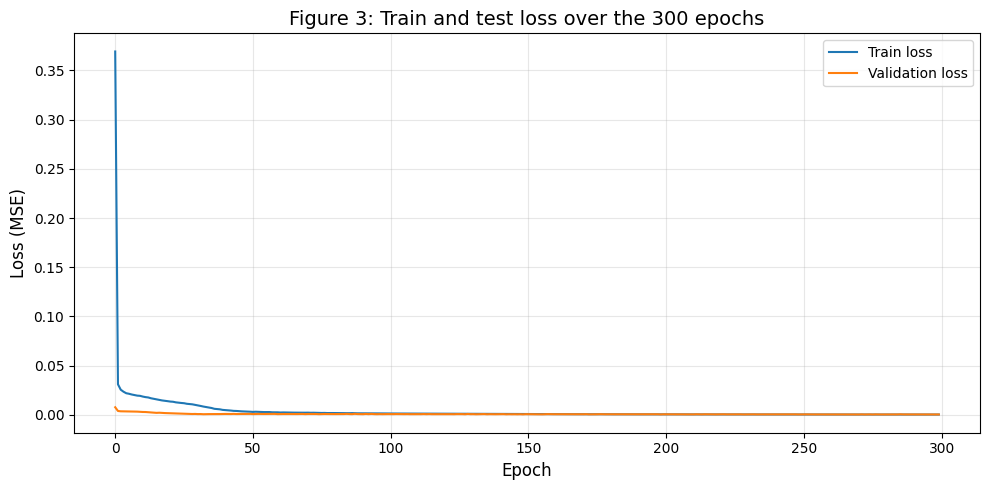

Figura 3 guardada como 'figure3_loss.png'


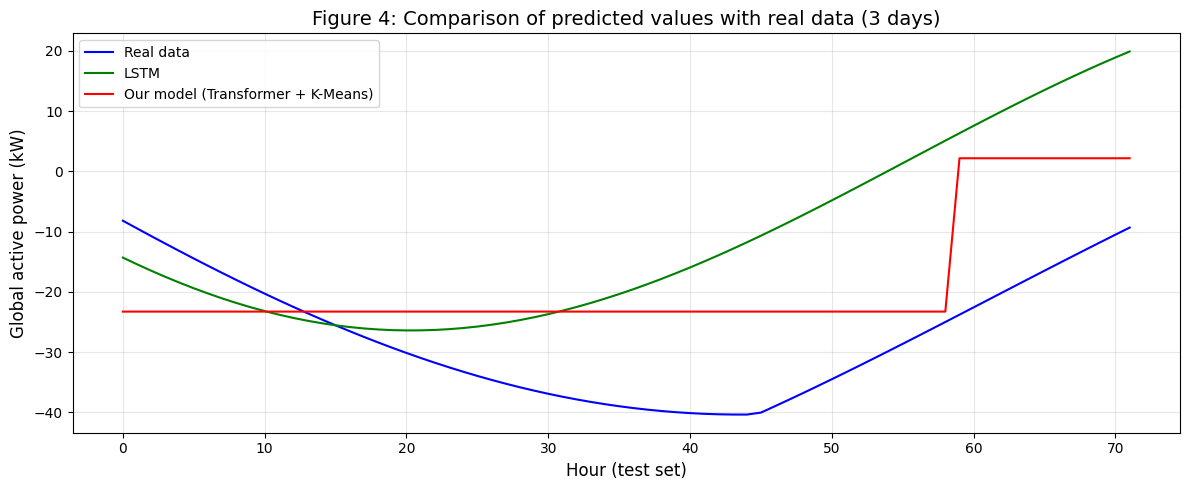

Figura 4 guardada como 'figure4_comparison.png'


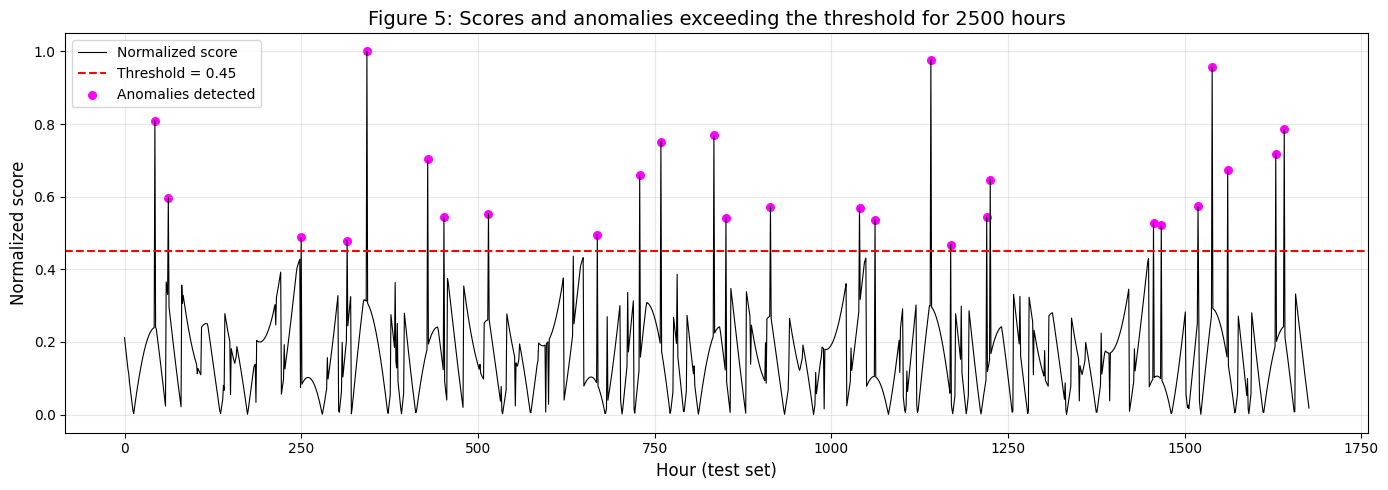

Figura 5 guardada como 'figure5_scores_anomalies.png'

Todas las figuras se han generado correctamente.


In [23]:
# ==================================================================
# GENERACIÓN DE GRÁFICAS (FIGURAS 3, 4 Y 5)
# Adaptado a los archivos de /content
# ==================================================================

import os
os.chdir("/content")

import numpy as np
import tensorflow as tf
import joblib
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = "/content"
tf.keras.config.enable_unsafe_deserialization()

# ------------------------------------------------------------------
# 1. Cargar datos
# ------------------------------------------------------------------
print("Cargando datos...")
data = np.load(f"{BASE_DIR}/ds3_preprocessed_rms.npz", allow_pickle=True)
X_test = data["X_test"]
y_test_norm = data["y_test"].flatten()

scaler_y = joblib.load(f"{BASE_DIR}/scaler_y.pkl")
min_active = scaler_y.data_min_[0]
max_active = scaler_y.data_max_[0]

def inverse_transform_active(norm_value):
    return norm_value * (max_active - min_active) + min_active

# ------------------------------------------------------------------
# 2. Cargar modelos
# ------------------------------------------------------------------
print("Cargando modelo Transformer...")
transformer = tf.keras.models.load_model(
    f"{BASE_DIR}/best_transformer.keras",
    compile=False,
    safe_mode=False
)

print("Cargando K-Means...")
kmeans_opt = joblib.load(f"{BASE_DIR}/kmeans_model.pkl")
centroids = kmeans_opt.cluster_centers_.flatten()

print("Cargando modelo LSTM...")
lstm_model = tf.keras.models.load_model(
    f"{BASE_DIR}/lstm_model.keras",
    compile=False,
    safe_mode=False
)

# ------------------------------------------------------------------
# 3. Predicciones
# ------------------------------------------------------------------
transformer_preds_norm = transformer.predict(X_test, verbose=0).flatten()
kmeans_corrected_norm = np.array([
    centroids[np.argmin(np.abs(transformer_preds_norm[i] - centroids))]
    for i in range(len(transformer_preds_norm))
])
lstm_preds_norm = lstm_model.predict(X_test, verbose=0).flatten()

y_test_orig = inverse_transform_active(y_test_norm)
our_preds_orig = inverse_transform_active(kmeans_corrected_norm)
lstm_preds_orig = inverse_transform_active(lstm_preds_norm)

# ------------------------------------------------------------------
# 4. Figura 3: Pérdida de entrenamiento
# ------------------------------------------------------------------
try:
    try:
        history = joblib.load(f"{BASE_DIR}/training_history.pkl")
    except Exception:
        with open(f"{BASE_DIR}/training_history.pkl", "rb") as f:
            history = pickle.load(f)

    plt.figure(figsize=(10,5))
    plt.plot(history['loss'], label='Train loss', linewidth=1.5)
    plt.plot(history['val_loss'], label='Validation loss', linewidth=1.5)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (MSE)', fontsize=12)
    plt.title('Figure 3: Train and test loss over the 300 epochs', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{BASE_DIR}/figure3_loss.png", dpi=150)
    plt.show()
    print("Figura 3 guardada como 'figure3_loss.png'")
except Exception as e:
    print(f"No se pudo generar Figura 3: {e}")

# ------------------------------------------------------------------
# 5. Figura 4: Comparación de predicciones (3 días)
# ------------------------------------------------------------------
start_idx = 0
end_idx = start_idx + 72
hours = np.arange(start_idx, end_idx)

plt.figure(figsize=(12,5))
plt.plot(hours, y_test_orig[start_idx:end_idx], 'b-', label='Real data', linewidth=1.5)
plt.plot(hours, lstm_preds_orig[start_idx:end_idx], 'g-', label='LSTM', linewidth=1.5)
plt.plot(hours, our_preds_orig[start_idx:end_idx], 'r-', label='Our model (Transformer + K-Means)', linewidth=1.5)
plt.xlabel('Hour (test set)', fontsize=12)
plt.ylabel('Global active power (kW)', fontsize=12)
plt.title('Figure 4: Comparison of predicted values with real data (3 days)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/figure4_comparison.png", dpi=150)
plt.show()
print("Figura 4 guardada como 'figure4_comparison.png'")

# ------------------------------------------------------------------
# 6. Inyección de anomalías y scores
# ------------------------------------------------------------------
hours_per_day = 24
num_days_test = len(y_test_orig) // hours_per_day
np.random.seed(42)
y_test_orig_with_anomalies = y_test_orig.copy()
anomaly_labels = np.zeros(len(y_test_orig), dtype=int)

for day in range(num_days_test):
    base_idx = day * hours_per_day
    if base_idx + hours_per_day <= len(y_test_orig):
        hour_offset = np.random.randint(0, hours_per_day)
        anomaly_idx = base_idx + hour_offset
        y_test_orig_with_anomalies[anomaly_idx] *= 2
        anomaly_labels[anomaly_idx] = 1

y_test_norm_with_anomalies = (y_test_orig_with_anomalies - min_active) / (max_active - min_active)

abs_errors = np.abs(kmeans_corrected_norm - y_test_norm_with_anomalies)
mean_abs_error = np.mean(abs_errors)
scores = abs_errors / mean_abs_error
scores_norm = (scores - np.min(scores)) / (np.max(scores) - np.min(scores))

threshold = 0.45

# ------------------------------------------------------------------
# 7. Figura 5: Scores y anomalías (2500 horas)
# ------------------------------------------------------------------
max_hours = min(2500, len(scores_norm))
time_axis = np.arange(max_hours)
anom_in_range = np.where((scores_norm > threshold) & (np.arange(len(scores_norm)) < max_hours))[0]

plt.figure(figsize=(14,5))
plt.plot(time_axis, scores_norm[:max_hours], 'k-', linewidth=0.8, label='Normalized score')
plt.axhline(y=threshold, color='r', linestyle='--', linewidth=1.5, label=f'Threshold = {threshold}')
plt.scatter(anom_in_range, scores_norm[anom_in_range], color='magenta', s=30, label='Anomalies detected')
plt.xlabel('Hour (test set)', fontsize=12)
plt.ylabel('Normalized score', fontsize=12)
plt.title('Figure 5: Scores and anomalies exceeding the threshold for 2500 hours', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/figure5_scores_anomalies.png", dpi=150)
plt.show()
print("Figura 5 guardada como 'figure5_scores_anomalies.png'")

print("\nTodas las figuras se han generado correctamente.")